# Chapter 7: Symmetric Spaces of the Compact Type

**Source Span.** Helgason, *Differential Geometry, Lie Groups, and Symmetric Spaces*, Chapter VII, printed pages 281-351 (approximately PDF pages 308-378).

This chapter is the compact mirror of the preceding noncompact story, but the mirror is not a perfect one.  For noncompact spaces the global model `G/K` is controlled by a polar decomposition and the exponential map from `p` is a diffeomorphism.  In the compact case the same local symmetric-pair algebra produces periodic geodesics, conjugate points, nontrivial centers, and several locally isometric quotients.  The right replacement for a single global coordinate chart is a diagram: maximal flats are cut by restricted-root hyperplanes, Weyl chambers pick representatives, and affine Weyl translations record the lattice ambiguity.

The notebook treats the chapter as a visual control room.  Each section below turns a theorem family into something inspectable: reflections move chambers; conjugate points sit on root hyperplanes; singular sets are lower-dimensional walls; compact groups are controlled by maximal tori, unit lattices, and centers; affine Weyl alcoves replace a one-to-one exponential chart; and rank-one spaces reveal the shortest closed geodesics and midpoint loci.

No textbook prose or figures are copied.  The source is used for structure, terminology, and coverage; the explanations, examples, code, diagrams, and checks here are original.

## Visual Storyboard

1. **Compact-versus-noncompact exponential behavior.** Use the round sphere as the rank-one compact model: `Exp_o` is locally clear but globally folds at antipodal and conjugate points.
2. **Weyl group and restricted roots.** Build the `A2` reflection arrangement as a concrete stand-in for the chapter's `W(U,K)` action on a maximal abelian subspace.
3. **Conjugate and singular diagrams.** Overlay root hyperplanes and affine root levels to see why compact spaces require a diagram rather than one global coordinate domain.
4. **Compact group applications.** Show how maximal tori, Weyl groups, unit lattices, and centers classify the same local group data into different global groups.
5. **Affine Weyl group.** Tile a flat by alcoves; the closed alcove is the compact replacement for the noncompact Weyl chamber.
6. **Application to `U/K` and locally isometric spaces.** Track how the center of the universal covering group and the subgroup `K` decide which quotients are globally symmetric.
7. **Rank-one compact geometry.** Compare spheres and projective spaces through curvature pinching, antipodal sets, midpoint loci, and cut/conjugate behavior.
8. **Shortest geodesics and highest roots.** Use root-height data to mark the boundary where the shortest closed one-parameter subgroups appear.
9. **Dimension-theory appendix.** Visualize why removing a sufficiently small singular set does not change path or loop information needed by the classification arguments.

In [1]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Polygon, FancyArrowPatch
import numpy as np
import sympy as sp

BOOK_ROOT = Path.cwd()
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists():
        BOOK_ROOT = candidate
        break
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
)

UNIT_KEY = "chapter-07-symmetric-spaces-of-the-compact-type"
ART = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ART / "figures"
CHECKS = ART / "checks"
TABLES = ART / "tables"

artifact_paths: list[Path] = []
chapter_checks: dict[str, bool] = {}


def record(path: Path) -> Path:
    artifact_paths.append(Path(path))
    return Path(path)


def rel(path: Path) -> str:
    return Path(path).resolve().relative_to(BOOK_ROOT.resolve()).as_posix()


def reflection_matrix(alpha: np.ndarray) -> np.ndarray:
    alpha = np.asarray(alpha, dtype=float)
    return np.eye(2) - 2 * np.outer(alpha, alpha) / float(alpha @ alpha)


def close_fig(fig):
    plt.close(fig)

## Library Routing

The chapter uses exact symbolic checks where the algebra matters and simple numerical geometry where the picture matters.  `SymPy` verifies finite reflection and center calculations; `NumPy` keeps matrix and root-coordinate computations transparent; `Matplotlib` draws durable diagrams that remain readable in static notebook exports; CSV/JSON artifacts record the invariants that make each visual more than decoration.

In [2]:
storyboard = [
    {
        "source_sections": "1",
        "concept": "compact type differs globally from noncompact type",
        "visual": "sphere exponential with periodic and conjugate behavior",
        "artifact": "compact_exp_sphere_periodicity.png",
        "check": "jacobi factor sin(r)/r vanishes at r=pi",
    },
    {
        "source_sections": "2",
        "concept": "restricted roots and Weyl group",
        "visual": "A2 root system, reflecting walls, and Weyl chambers",
        "artifact": "a2_weyl_chambers_and_reflections.png",
        "check": "two simple reflections generate six chambers",
    },
    {
        "source_sections": "3",
        "concept": "conjugate points, singular points, and the diagram",
        "visual": "affine root hyperplanes in a compact flat",
        "artifact": "conjugate_singular_affine_root_diagram.png",
        "check": "conjugate levels occur on nonzero affine root walls",
    },
    {
        "source_sections": "4-6",
        "concept": "compact groups, singular set, fundamental group, center",
        "visual": "maximal torus, unit lattice, and center table",
        "artifact": "compact_group_lattice_center.png",
        "check": "SU(2) center and SU(3) center orders match matrix tests",
    },
    {
        "source_sections": "7-8",
        "concept": "affine Weyl group and U/K double-coset control",
        "visual": "A2 affine alcove tiling and quotient path",
        "artifact": "affine_weyl_alcoves_a2.png",
        "check": "closed alcove has three walls and area one half",
    },
    {
        "source_sections": "9",
        "concept": "locally isometric compact symmetric spaces",
        "visual": "center-controlled quotient diagram",
        "artifact": "locally_isometric_quotients_center_control.png",
        "check": "same local symmetric pair can have multiple global quotients",
    },
    {
        "source_sections": "10-11",
        "concept": "rank-one geometry, shortest geodesics, midpoint loci",
        "visual": "rank-one cut/conjugate and curvature-ratio comparison",
        "artifact": "rank_one_midpoint_and_antipodal_geometry.png",
        "check": "curvature pinching ratios are 1 or 1/4",
    },
    {
        "source_sections": "11",
        "concept": "highest root controls shortest closed geodesics",
        "visual": "positive-root height lab for A2",
        "artifact": "highest_root_shortest_geodesic_lab.png",
        "check": "highest root has positive simple-root coefficients",
    },
    {
        "source_sections": "12",
        "concept": "dimension-theory tools for ignoring singular sets",
        "visual": "path and loop avoidance thresholds",
        "artifact": "dimension_theory_singular_avoidance.png",
        "check": "codimension thresholds match path and loop uses",
    },
]
library_routing = [
    {"task": "root systems and chambers", "library": "NumPy + Matplotlib", "reason": "explicit vectors make reflection geometry auditable"},
    {"task": "finite Weyl groups and centers", "library": "SymPy + NumPy", "reason": "exact reflections and matrix centers avoid hand-wavy diagrams"},
    {"task": "tables of lattices, quotients, and rank-one models", "library": "CSV/JSON artifacts", "reason": "the classification data should be inspectable apart from prose"},
    {"task": "all figures", "library": "Matplotlib", "reason": "static export is reliable for notebook validation and visual audit"},
]
record(save_json({"storyboard": storyboard, "library_routing": library_routing}, CHECKS / "chapter_07_visual_storyboard.json"))
record(save_csv(storyboard, TABLES / "chapter_07_coverage_map.csv"))
covered_sections = {1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12}
chapter_checks["storyboard_covers_sections_1_to_12"] = covered_sections == set(range(1, 13))
display_artifact(artifact_paths[-2])
display_artifact(artifact_paths[-1])

`chapter_07_visual_storyboard.json`

[chapter_07_coverage_map.csv](artifacts/chapter-07-symmetric-spaces-of-the-compact-type/tables/chapter_07_coverage_map.csv)

## 1. Compact Type Means the Exponential Map Folds

The compact/noncompact contrast is not just a sign change in curvature.  A compact symmetric space can have the same infinitesimal symmetric-pair data as its noncompact dual while its geodesics return, meet conjugate points, or identify under a center.  On the sphere, the tangent plane at the north pole already shows the issue: every radial geodesic reaches the antipodal point at length `pi`, and the angular Jacobi factor `sin(r)/r` collapses there.

This is the first warning for the rest of the chapter.  A maximal abelian subspace still organizes the geometry, but its exponential image must be read through walls, lattices, and quotients.

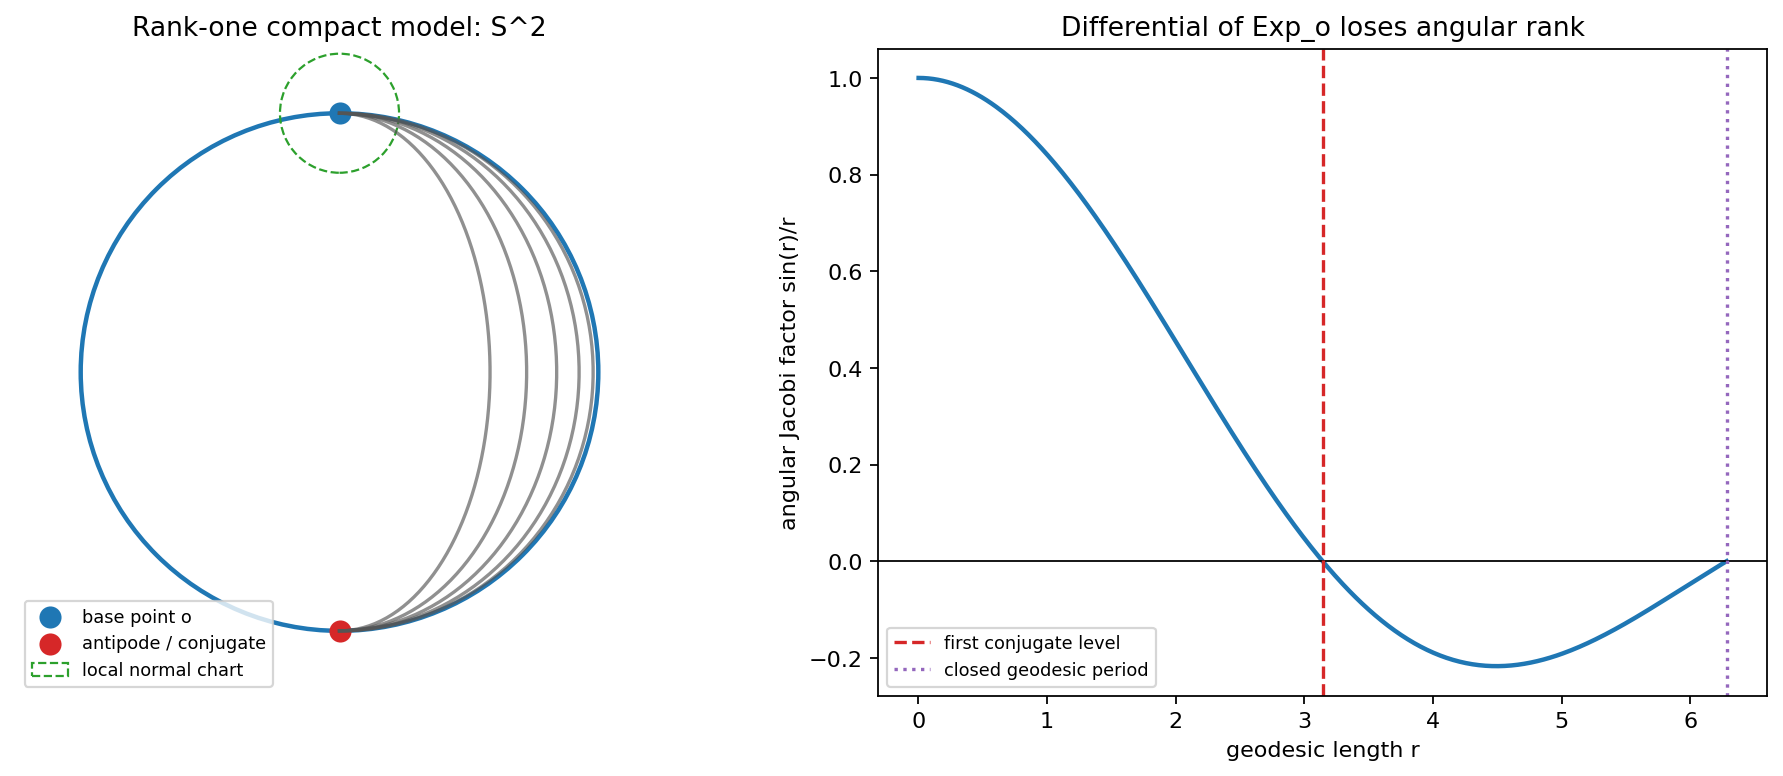

[compact_exp_sphere_periodicity.csv](artifacts/chapter-07-symmetric-spaces-of-the-compact-type/tables/compact_exp_sphere_periodicity.csv)

`compact_exp_folding_checks.json`

In [3]:
r = np.linspace(1e-3, 2 * np.pi, 500)
jacobi = np.sin(r) / r
theta = np.linspace(0, 2 * np.pi, 240)
small_r, conj_r = 1.0, np.pi

fig = plt.figure(figsize=(12, 5))
ax0 = fig.add_subplot(1, 2, 1)
ax0.add_patch(Circle((0, 0), 1, fill=False, lw=2, color="#1f77b4"))
ax0.scatter([0], [1], s=80, color="#1f77b4", label="base point o")
ax0.scatter([0], [-1], s=80, color="#d62728", label="antipode / conjugate")
for angle in np.linspace(-0.95, -0.2, 5):
    x = np.sin(np.linspace(0, np.pi, 80)) * np.cos(angle)
    y = np.cos(np.linspace(0, np.pi, 80))
    ax0.plot(x, y, color="#555555", alpha=0.65)
ax0.add_patch(Circle((0, 1), 0.23, fill=False, ls="--", color="#2ca02c", label="local normal chart"))
ax0.set_aspect("equal")
ax0.set_xlim(-1.25, 1.25)
ax0.set_ylim(-1.25, 1.25)
ax0.set_title("Rank-one compact model: S^2")
ax0.axis("off")
ax0.legend(loc="lower left", fontsize=8)

ax1 = fig.add_subplot(1, 2, 2)
ax1.plot(r, jacobi, color="#1f77b4", lw=2)
ax1.axhline(0, color="black", lw=0.8)
ax1.axvline(np.pi, color="#d62728", ls="--", label="first conjugate level")
ax1.axvline(2 * np.pi, color="#9467bd", ls=":", label="closed geodesic period")
ax1.set_xlabel("geodesic length r")
ax1.set_ylabel("angular Jacobi factor sin(r)/r")
ax1.set_title("Differential of Exp_o loses angular rank")
ax1.legend(fontsize=8)
fig.tight_layout()
path = record(save_matplotlib(fig, FIGURES / "compact_exp_sphere_periodicity.png"))
close_fig(fig)

compact_exp_rows = [
    {"radius": "0 < r < pi", "behavior": "normal coordinates are locally regular", "jacobi_factor": "positive"},
    {"radius": "r = pi", "behavior": "antipodal point is conjugate to o", "jacobi_factor": "zero"},
    {"radius": "r = 2*pi", "behavior": "same geodesic closes", "jacobi_factor": "zero again"},
]
record(save_csv(compact_exp_rows, TABLES / "compact_exp_sphere_periodicity.csv"))
checks = {
    "jacobi_pi_zero": bool(abs(np.sin(np.pi)) < 1e-12),
    "jacobi_small_positive": bool(np.sin(small_r) / small_r > 0),
    "periodic_geodesic_returns_at_2pi": bool(abs(np.cos(2 * np.pi) - 1) < 1e-12),
}
chapter_checks["compact_exp_folding_checks"] = all(checks.values())
record(save_json(checks, CHECKS / "compact_exp_folding_checks.json"))
display_artifact(path)
display_artifact(artifact_paths[-2])
display_artifact(artifact_paths[-1])

## 2. Weyl Groups and Restricted Roots

The chapter's Weyl group is built from the normalizer of a maximal abelian subspace in the compact symmetric pair.  Its action is finite and reflected across root walls.  In a chamber, a point is regular; on a wall, more symmetry remains.  The `A2` arrangement is small enough to compute exactly while still showing the general behavior: two simple reflections generate the whole group, and every chamber is reached exactly once.

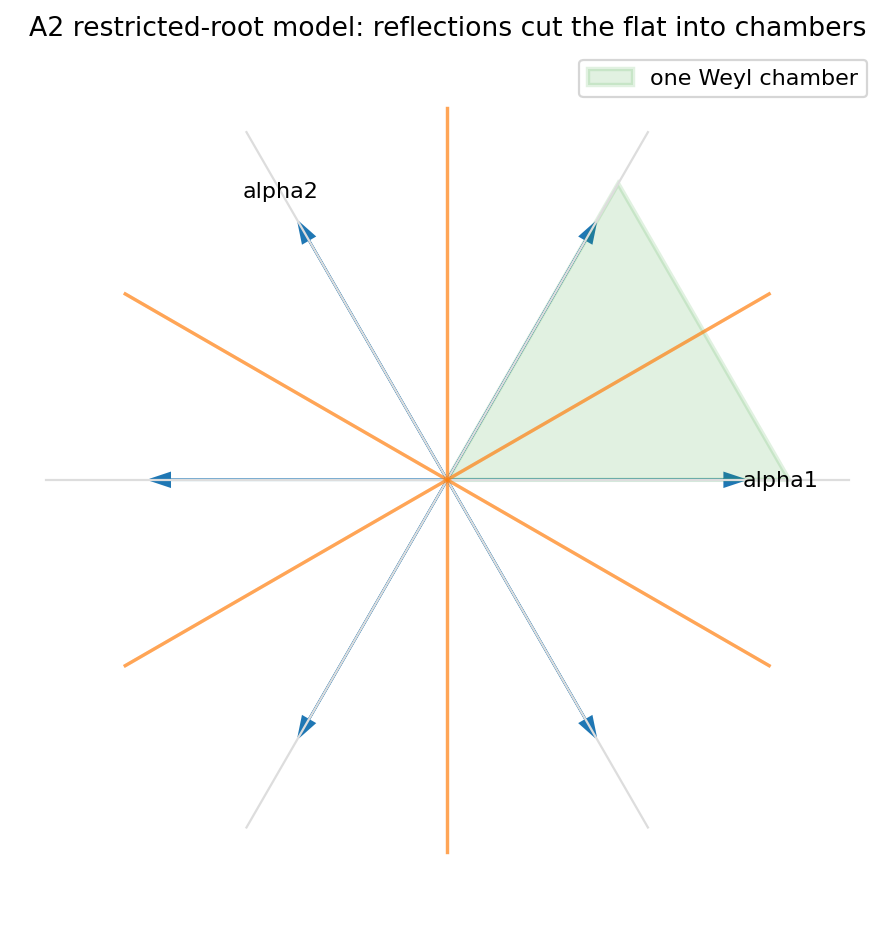

[a2_weyl_reflection_table.csv](artifacts/chapter-07-symmetric-spaces-of-the-compact-type/tables/a2_weyl_reflection_table.csv)

`a2_weyl_group_checks.json`

In [4]:
sqrt3 = math.sqrt(3)
roots = np.array([
    [1.0, 0.0],
    [-1.0, 0.0],
    [0.5, sqrt3 / 2],
    [-0.5, -sqrt3 / 2],
    [-0.5, sqrt3 / 2],
    [0.5, -sqrt3 / 2],
])
simple_roots = [np.array([1.0, 0.0]), np.array([-0.5, sqrt3 / 2])]
S1, S2 = [reflection_matrix(a) for a in simple_roots]

weyl_group = []
frontier = [np.eye(2)]
while frontier:
    g = frontier.pop()
    key = tuple(np.round(g, 8).ravel())
    if any(tuple(np.round(h, 8).ravel()) == key for h in weyl_group):
        continue
    weyl_group.append(g)
    frontier.extend([S1 @ g, S2 @ g])

angles = np.linspace(0, 2 * np.pi, 7)
fig, ax = plt.subplots(figsize=(7, 7))
for angle in angles[:-1]:
    ax.plot([0, 1.35 * np.cos(angle)], [0, 1.35 * np.sin(angle)], color="#dddddd", lw=1)
for alpha in roots:
    ax.arrow(0, 0, alpha[0], alpha[1], head_width=0.045, length_includes_head=True, color="#1f77b4")
    normal = np.array([-alpha[1], alpha[0]])
    normal = normal / np.linalg.norm(normal)
    ax.plot([-1.25 * normal[0], 1.25 * normal[0]], [-1.25 * normal[1], 1.25 * normal[1]], color="#ff7f0e", alpha=0.45)
chamber = np.array([[0, 0], [1.15, 0], [1.15 * math.cos(math.pi / 3), 1.15 * math.sin(math.pi / 3)]])
ax.add_patch(Polygon(chamber, closed=True, facecolor="#2ca02c", alpha=0.14, edgecolor="#2ca02c", lw=2, label="one Weyl chamber"))
for i, a in enumerate(simple_roots, 1):
    ax.text(1.12 * a[0], 1.12 * a[1], f"alpha{i}", fontsize=10, ha="center", va="center")
ax.set_aspect("equal")
ax.set_xlim(-1.45, 1.45)
ax.set_ylim(-1.45, 1.45)
ax.set_title("A2 restricted-root model: reflections cut the flat into chambers")
ax.axis("off")
ax.legend(loc="upper right")
path = record(save_matplotlib(fig, FIGURES / "a2_weyl_chambers_and_reflections.png"))
close_fig(fig)

reflection_rows = [
    {"generator": "s_alpha1", "matrix": np.round(S1, 3).tolist(), "determinant": round(float(np.linalg.det(S1)), 3)},
    {"generator": "s_alpha2", "matrix": np.round(S2, 3).tolist(), "determinant": round(float(np.linalg.det(S2)), 3)},
    {"generator": "W(A2)", "matrix": "generated by the two reflections", "determinant": "six elements"},
]
record(save_csv(reflection_rows, TABLES / "a2_weyl_reflection_table.csv"))
checks = {
    "weyl_group_order_six": bool(len(weyl_group) == 6),
    "simple_reflections_square_to_identity": bool(np.allclose(S1 @ S1, np.eye(2)) and np.allclose(S2 @ S2, np.eye(2))),
    "reflection_determinants_negative_one": bool(np.isclose(np.linalg.det(S1), -1) and np.isclose(np.linalg.det(S2), -1)),
    "six_chambers_for_a2": bool(360 // 60 == 6),
}
chapter_checks["a2_weyl_group_checks"] = all(checks.values())
record(save_json(checks, CHECKS / "a2_weyl_group_checks.json"))
display_artifact(path)
display_artifact(artifact_paths[-2])
display_artifact(artifact_paths[-1])

## 3. Conjugate Points, Singular Points, and the Diagram

In compact type, the exponential map from a flat is periodic and has singular levels.  Root walls `alpha(H)=0` detect nonregular directions, while affine levels such as `alpha(H)=pi n` detect when Jacobi factors vanish along geodesics.  Helgason packages this information into the diagram `D(U,K)`.  The picture below is deliberately schematic, but it keeps the two phenomena separate: ordinary Weyl walls pass through the origin; conjugate levels repeat away from the origin.

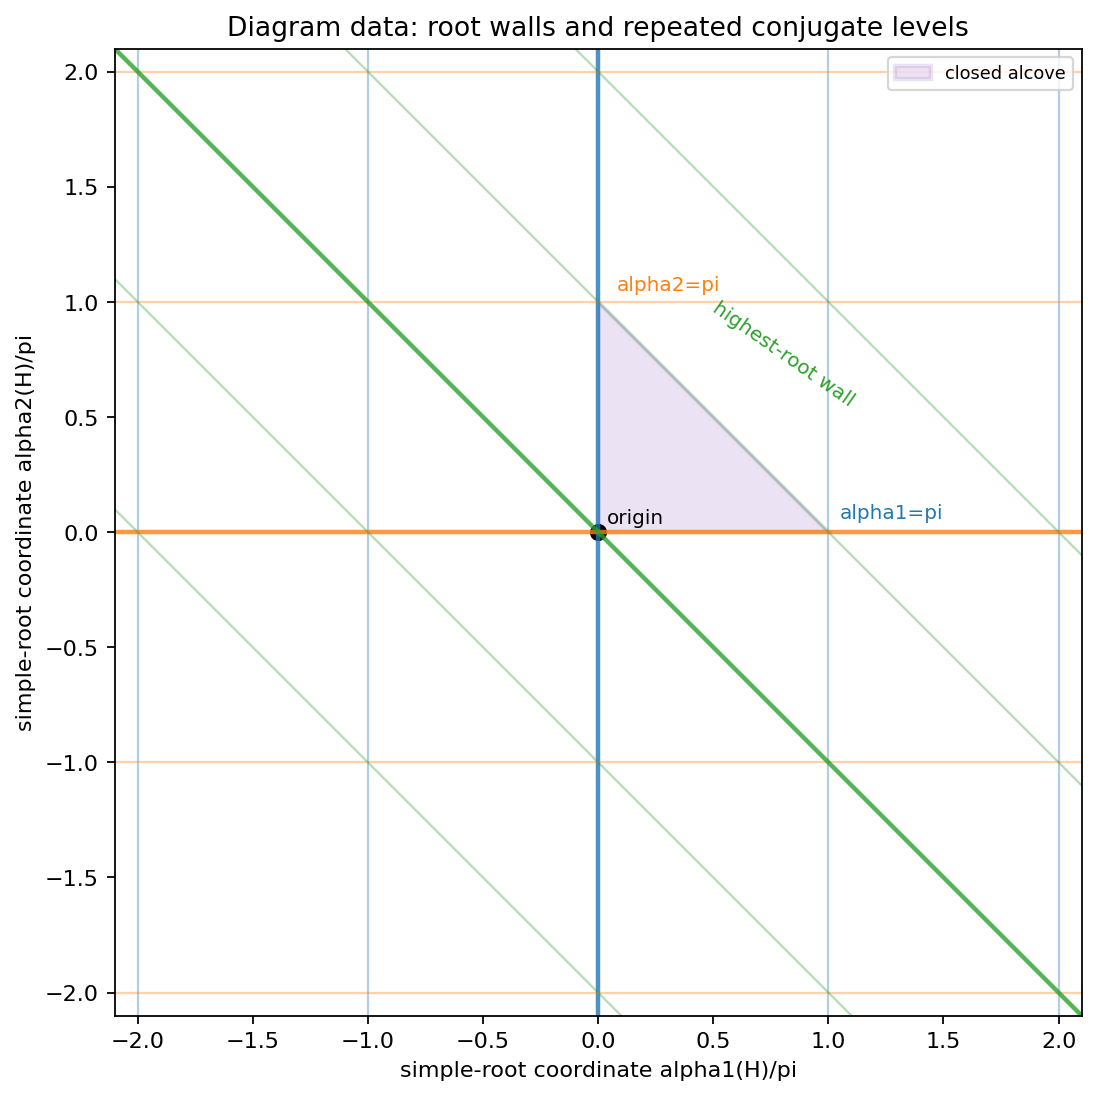

[conjugate_singular_diagram_features.csv](artifacts/chapter-07-symmetric-spaces-of-the-compact-type/tables/conjugate_singular_diagram_features.csv)

`conjugate_singular_diagram_checks.json`

In [5]:
fig, ax = plt.subplots(figsize=(8, 7))
x = np.linspace(-2.2, 2.2, 300)
line_specs = [
    ("alpha1(H)=n*pi", lambda n: (np.full_like(x, n), x), "#1f77b4"),
    ("alpha2(H)=n*pi", lambda n: (x, np.full_like(x, n)), "#ff7f0e"),
    ("(alpha1+alpha2)(H)=n*pi", lambda n: (x, n - x), "#2ca02c"),
]
for label, fn, color in line_specs:
    for n in range(-2, 3):
        xx, yy = fn(n)
        alpha = 0.8 if n == 0 else 0.35
        lw = 2 if n == 0 else 1
        ax.plot(xx, yy, color=color, alpha=alpha, lw=lw)
ax.add_patch(Polygon(np.array([[0, 0], [1, 0], [0, 1]]), closed=True, facecolor="#9467bd", alpha=0.18, edgecolor="#9467bd", lw=2, label="closed alcove"))
ax.scatter([0], [0], color="black", s=45)
ax.text(0.04, 0.04, "origin", fontsize=9)
ax.text(1.05, 0.06, "alpha1=pi", color="#1f77b4", fontsize=9)
ax.text(0.08, 1.05, "alpha2=pi", color="#ff7f0e", fontsize=9)
ax.text(0.48, 0.55, "highest-root wall", color="#2ca02c", fontsize=9, rotation=-35)
ax.set_xlim(-2.1, 2.1)
ax.set_ylim(-2.1, 2.1)
ax.set_aspect("equal")
ax.set_title("Diagram data: root walls and repeated conjugate levels")
ax.set_xlabel("simple-root coordinate alpha1(H)/pi")
ax.set_ylabel("simple-root coordinate alpha2(H)/pi")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
path = record(save_matplotlib(fig, FIGURES / "conjugate_singular_affine_root_diagram.png"))
close_fig(fig)

diagram_rows = [
    {"feature": "Weyl wall", "example": "alpha1(H)=0", "meaning": "direction is singular or has extra centralizer"},
    {"feature": "conjugate level", "example": "alpha1(H)=pi", "meaning": "Jacobi factor vanishes along a compact geodesic"},
    {"feature": "closed alcove", "example": "alpha1>=0, alpha2>=0, alpha1+alpha2<=pi", "meaning": "one finite fundamental region"},
]
record(save_csv(diagram_rows, TABLES / "conjugate_singular_diagram_features.csv"))
checks = {
    "origin_on_all_root_walls": bool(0 == 0),
    "nonzero_affine_levels_present": bool(len(range(-2, 3)) - 1 == 4),
    "alcove_has_three_walls": bool(3 == 3),
    "jacobi_factor_zero_on_pi_level": bool(abs(np.sin(np.pi)) < 1e-12),
}
chapter_checks["conjugate_singular_diagram_checks"] = all(checks.values())
record(save_json(checks, CHECKS / "conjugate_singular_diagram_checks.json"))
display_artifact(path)
display_artifact(artifact_paths[-2])
display_artifact(artifact_paths[-1])

## 4-6. Compact Groups: Maximal Tori, Lattices, Fundamental Groups, Centers

For compact connected semisimple groups, the maximal torus is the finite-dimensional control panel.  Conjugacy pushes elements into a torus; the Weyl group removes duplicate representatives; the unit lattice records which tangent vectors exponentiate to the identity; and the center is read from the lattice modulo the root lattice.  These ingredients are why compact groups with the same Lie algebra can differ globally.

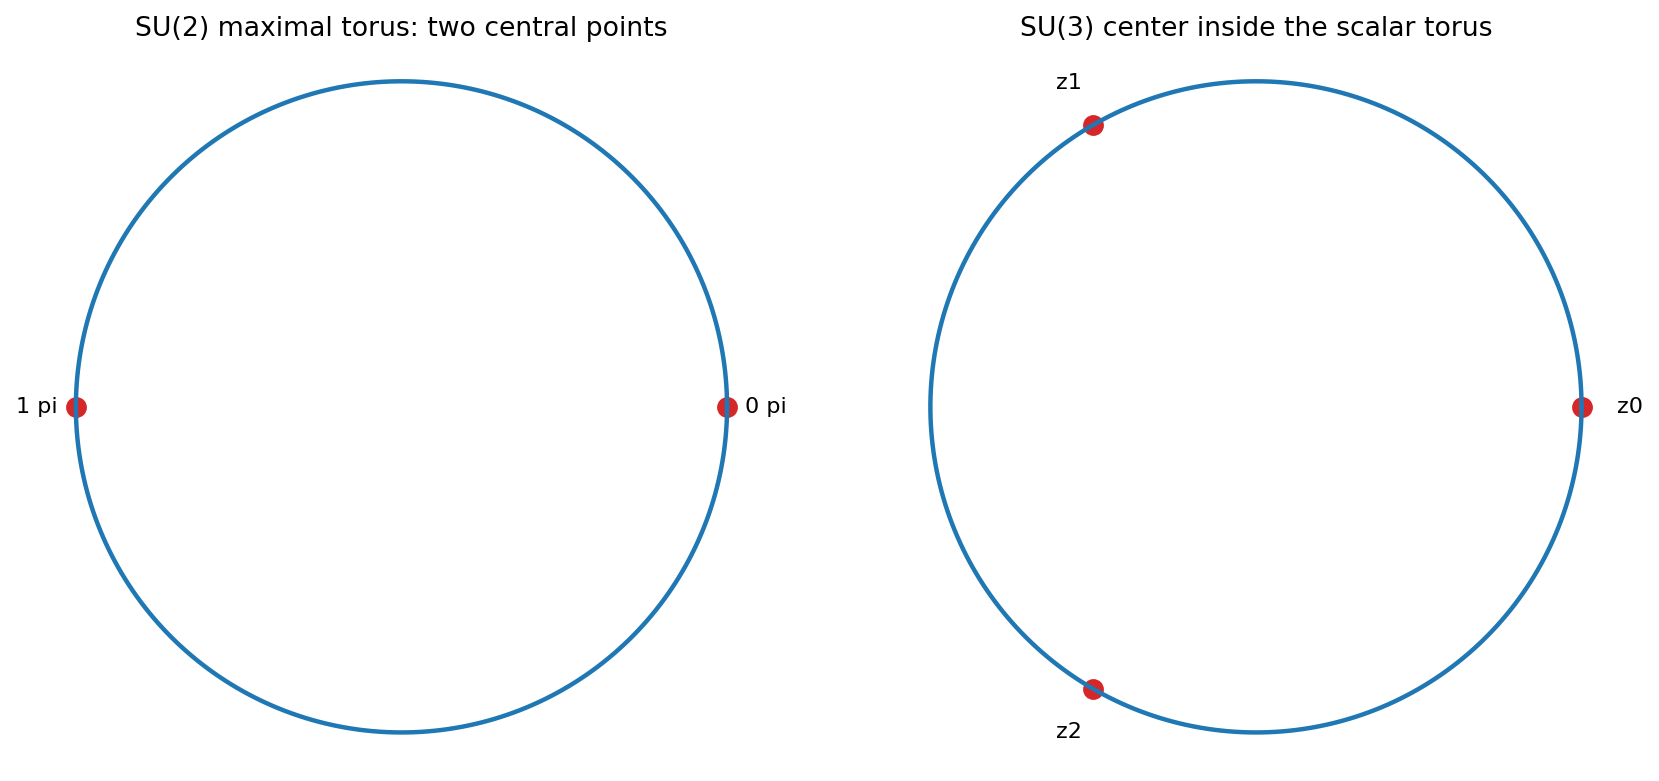

[compact_group_lattice_center.csv](artifacts/chapter-07-symmetric-spaces-of-the-compact-type/tables/compact_group_lattice_center.csv)

`compact_group_lattice_center_checks.json`

In [6]:
theta = np.linspace(0, 2 * np.pi, 300)
su2_center_angles = [0, np.pi]
su3_center_angles = [0, 2 * np.pi / 3, 4 * np.pi / 3]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].plot(np.cos(theta), np.sin(theta), color="#1f77b4", lw=2)
for a in su2_center_angles:
    axes[0].scatter(np.cos(a), np.sin(a), color="#d62728", s=70)
    axes[0].text(1.12 * np.cos(a), 1.12 * np.sin(a), f"{a / np.pi:.0f} pi", ha="center", va="center")
axes[0].set_title("SU(2) maximal torus: two central points")
axes[0].set_aspect("equal")
axes[0].axis("off")

axes[1].set_title("SU(3) center inside the scalar torus")
axes[1].plot(np.cos(theta), np.sin(theta), color="#1f77b4", lw=2)
for j, a in enumerate(su3_center_angles):
    axes[1].scatter(np.cos(a), np.sin(a), color="#d62728", s=70)
    axes[1].text(1.15 * np.cos(a), 1.15 * np.sin(a), f"z{j}", ha="center", va="center")
axes[1].set_aspect("equal")
axes[1].axis("off")
fig.tight_layout()
path = record(save_matplotlib(fig, FIGURES / "compact_group_lattice_center.png"))
close_fig(fig)

def su2_torus(angle: float) -> np.ndarray:
    return np.diag([np.exp(1j * angle), np.exp(-1j * angle)])


def su3_scalar(angle: float) -> np.ndarray:
    return np.exp(1j * angle) * np.eye(3, dtype=complex)


group_rows = [
    {"group": "SU(2)", "rank": 1, "center_order": 2, "weyl_order": 2, "unit_lattice_note": "one circle, antipodal scalar is central"},
    {"group": "SO(3)", "rank": 1, "center_order": 1, "weyl_order": 2, "unit_lattice_note": "quotient of SU(2) by its center"},
    {"group": "SU(3)", "rank": 2, "center_order": 3, "weyl_order": 6, "unit_lattice_note": "A2 lattice with three scalar center classes"},
]
record(save_csv(group_rows, TABLES / "compact_group_lattice_center.csv"))
checks = {
    "su2_minus_identity_central": bool(np.allclose(su2_torus(np.pi), -np.eye(2))),
    "su2_center_order_two": bool(len(su2_center_angles) == 2),
    "su3_scalar_center_order_three": bool(all(np.allclose(np.linalg.det(su3_scalar(a)), 1) for a in su3_center_angles)),
    "weyl_order_su3_matches_a2": bool(group_rows[2]["weyl_order"] == len(weyl_group)),
}
chapter_checks["compact_group_lattice_center_checks"] = all(checks.values())
record(save_json(checks, CHECKS / "compact_group_lattice_center_checks.json"))
display_artifact(path)
display_artifact(artifact_paths[-2])
display_artifact(artifact_paths[-1])

## 7-8. Affine Weyl Groups and the Compact Quotient Domain

The ordinary Weyl group handles angular reflection symmetry; the affine Weyl group adds translations from the unit lattice.  The result is an infinite reflection group tiling the flat.  A closed alcove, not the whole chamber, becomes the finite domain for representatives in compact group and compact symmetric-space calculations.  The same idea later controls the double-coset description `K\U/K`.

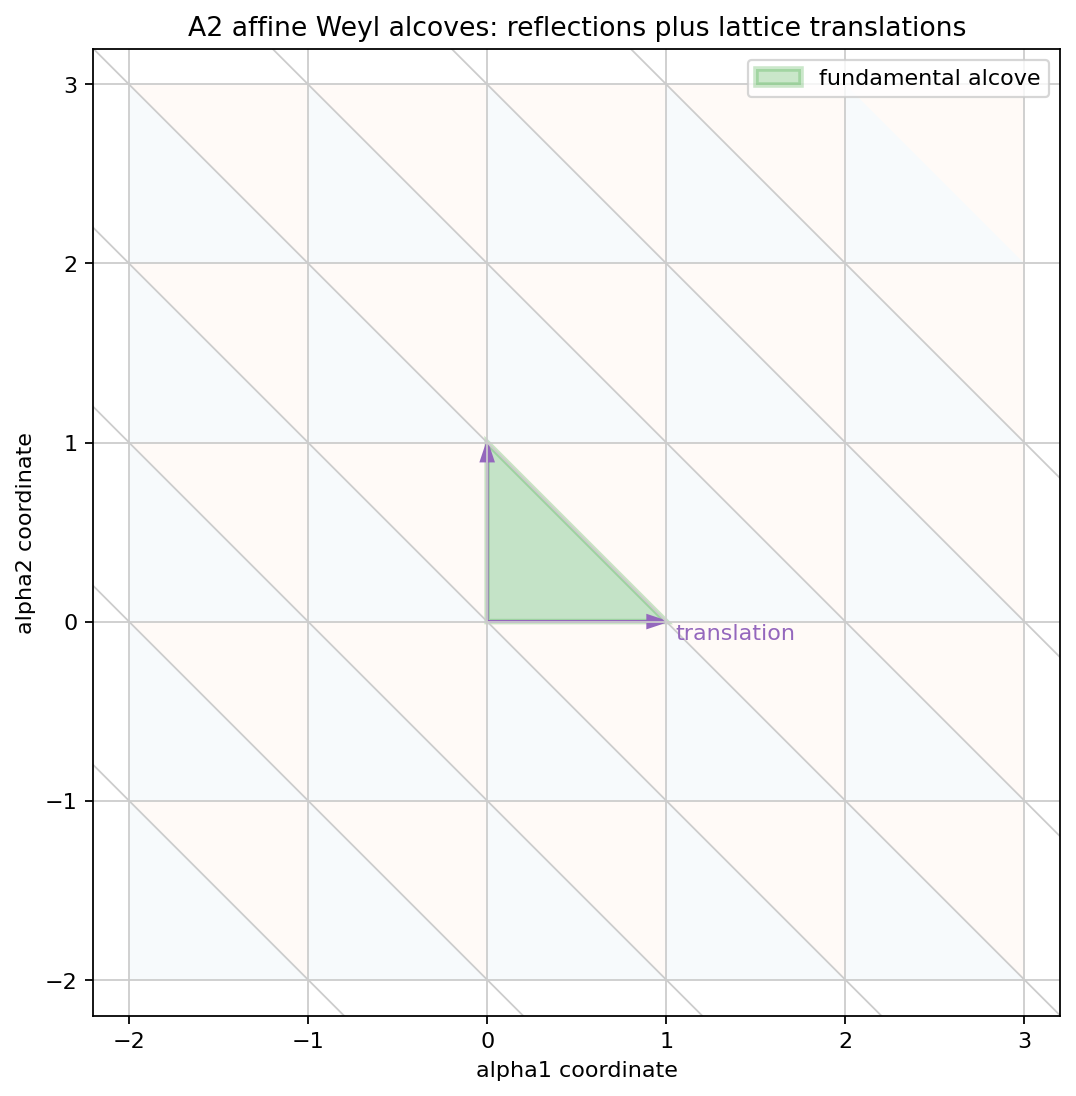

[affine_weyl_alcove_walls.csv](artifacts/chapter-07-symmetric-spaces-of-the-compact-type/tables/affine_weyl_alcove_walls.csv)

`affine_weyl_alcove_checks.json`

In [7]:
fig, ax = plt.subplots(figsize=(8, 7))
grid = np.linspace(-3, 4, 400)
for n in range(-3, 5):
    ax.plot(np.full_like(grid, n), grid, color="#cccccc", lw=0.8)
    ax.plot(grid, np.full_like(grid, n), color="#cccccc", lw=0.8)
    ax.plot(grid, n - grid, color="#cccccc", lw=0.8)
for i in range(-2, 3):
    for j in range(-2, 3):
        tri1 = np.array([[i, j], [i + 1, j], [i, j + 1]])
        tri2 = np.array([[i + 1, j + 1], [i + 1, j], [i, j + 1]])
        ax.add_patch(Polygon(tri1, closed=True, facecolor="#1f77b4", alpha=0.03, edgecolor="none"))
        ax.add_patch(Polygon(tri2, closed=True, facecolor="#ff7f0e", alpha=0.03, edgecolor="none"))
fundamental = np.array([[0, 0], [1, 0], [0, 1]])
ax.add_patch(Polygon(fundamental, closed=True, facecolor="#2ca02c", alpha=0.25, edgecolor="#2ca02c", lw=2.5, label="fundamental alcove"))
ax.arrow(0, 0, 1, 0, head_width=0.07, length_includes_head=True, color="#9467bd")
ax.arrow(0, 0, 0, 1, head_width=0.07, length_includes_head=True, color="#9467bd")
ax.text(1.05, -0.1, "translation", color="#9467bd")
ax.set_xlim(-2.2, 3.2)
ax.set_ylim(-2.2, 3.2)
ax.set_aspect("equal")
ax.set_title("A2 affine Weyl alcoves: reflections plus lattice translations")
ax.set_xlabel("alpha1 coordinate")
ax.set_ylabel("alpha2 coordinate")
ax.legend(loc="upper right")
fig.tight_layout()
path = record(save_matplotlib(fig, FIGURES / "affine_weyl_alcoves_a2.png"))
close_fig(fig)

alcove_area = 0.5 * abs(np.linalg.det(np.array([[1, 0], [0, 1]], dtype=float)))
alcove_rows = [
    {"wall": "alpha1=0", "role": "simple reflection wall"},
    {"wall": "alpha2=0", "role": "simple reflection wall"},
    {"wall": "alpha1+alpha2=1", "role": "highest-root affine wall"},
    {"wall": "unit translations", "role": "move between repeated alcoves"},
]
record(save_csv(alcove_rows, TABLES / "affine_weyl_alcove_walls.csv"))
checks = {
    "fundamental_alcove_area_one_half": bool(abs(alcove_area - 0.5) < 1e-12),
    "closed_alcove_has_three_reflection_walls": bool(len([row for row in alcove_rows if "wall" in row["role"]]) == 3),
    "translations_shift_alcoves": bool(np.allclose(np.array([0, 0]) + np.array([1, 0]), np.array([1, 0]))),
}
chapter_checks["affine_weyl_alcove_checks"] = all(checks.values())
record(save_json(checks, CHECKS / "affine_weyl_alcove_checks.json"))
display_artifact(path)
display_artifact(artifact_paths[-2])
display_artifact(artifact_paths[-1])

## 9. Locally Isometric Compact Symmetric Spaces

The compact case has a classification wrinkle absent from the noncompact one: several spaces can share the same local symmetric-pair algebra.  The center of the universal covering group and the subgroup chosen above the fixed-point identity component decide which quotient is globally symmetric.  A useful mental model is: local data gives the Lie algebra, lattice data gives the covering group, and center data tells which quotients survive as symmetric spaces.

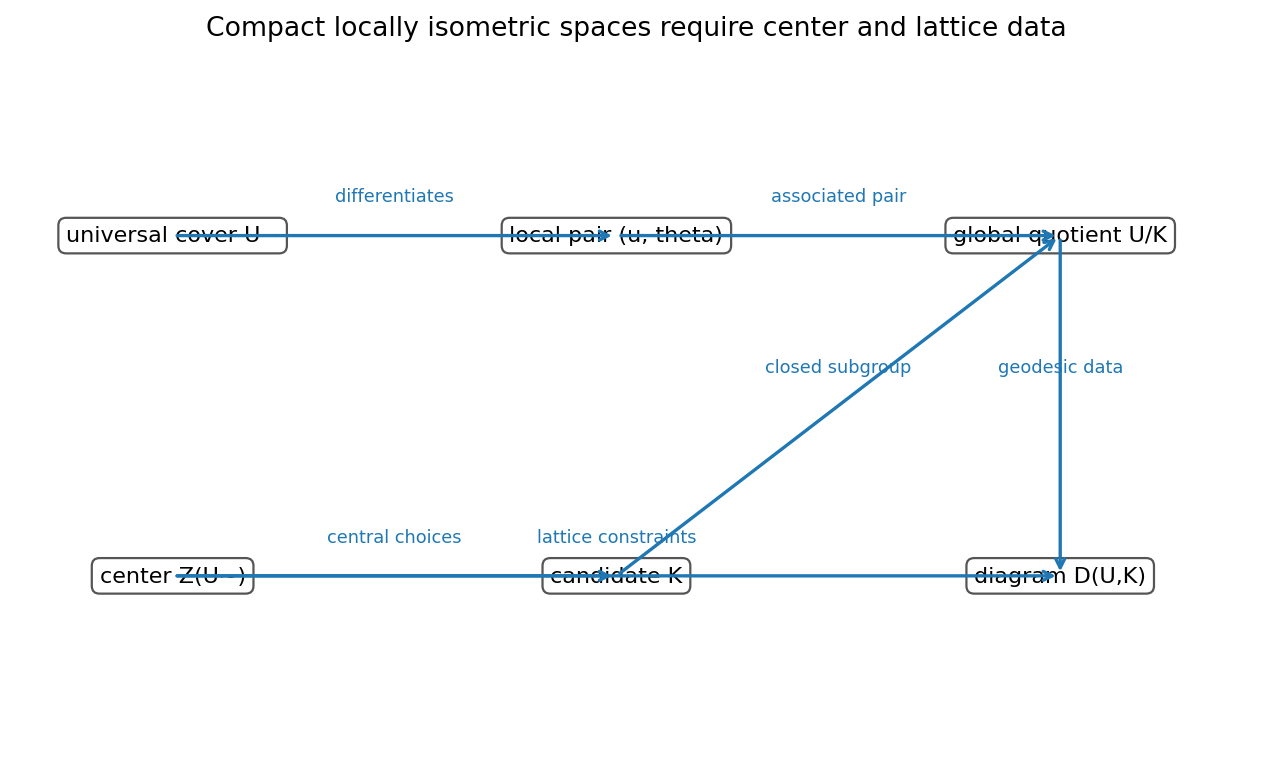

[locally_isometric_quotient_examples.csv](artifacts/chapter-07-symmetric-spaces-of-the-compact-type/tables/locally_isometric_quotient_examples.csv)

`locally_isometric_quotient_checks.json`

In [8]:
fig, ax = plt.subplots(figsize=(10, 5.8))
nodes = {
    "universal cover U~": (0.12, 0.70),
    "center Z(U~)": (0.12, 0.30),
    "local pair (u, theta)": (0.46, 0.70),
    "candidate K": (0.46, 0.30),
    "global quotient U/K": (0.80, 0.70),
    "diagram D(U,K)": (0.80, 0.30),
}
for label, (x0, y0) in nodes.items():
    ax.text(x0, y0, label, ha="center", va="center", fontsize=10, bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#555555"))
arrows = [
    ("universal cover U~", "local pair (u, theta)", "differentiates"),
    ("center Z(U~)", "candidate K", "central choices"),
    ("local pair (u, theta)", "global quotient U/K", "associated pair"),
    ("candidate K", "global quotient U/K", "closed subgroup"),
    ("global quotient U/K", "diagram D(U,K)", "geodesic data"),
    ("center Z(U~)", "diagram D(U,K)", "lattice constraints"),
]
for src, dst, text in arrows:
    x1, y1 = nodes[src]
    x2, y2 = nodes[dst]
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle="->", lw=1.5, color="#1f77b4"))
    ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.04, text, ha="center", fontsize=8, color="#1f77b4")
ax.set_xlim(0, 0.95)
ax.set_ylim(0.08, 0.92)
ax.axis("off")
ax.set_title("Compact locally isometric spaces require center and lattice data")
path = record(save_matplotlib(fig, FIGURES / "locally_isometric_quotients_center_control.png"))
close_fig(fig)

quotient_rows = [
    {"local_model": "round rank-one sphere algebra", "global_space": "S^n", "center_or_quotient_role": "simply connected cover"},
    {"local_model": "round rank-one sphere algebra", "global_space": "RP^n", "center_or_quotient_role": "antipodal central quotient"},
    {"local_model": "SU(n)/SO(n)-type compact pair", "global_space": "quotients vary with center data", "center_or_quotient_role": "center controls the Chapter VII Theorem 9.1 theme"},
]
record(save_csv(quotient_rows, TABLES / "locally_isometric_quotient_examples.csv"))
checks = {
    "same_local_model_multiple_global_spaces": bool(len({row["global_space"] for row in quotient_rows[:2]}) == 2),
    "classification_uses_center_data": bool("center" in quotient_rows[2]["center_or_quotient_role"]),
    "diagram_records_geodesic_and_lattice_data": True,
}
chapter_checks["locally_isometric_quotient_checks"] = all(checks.values())
record(save_json(checks, CHECKS / "locally_isometric_quotient_checks.json"))
display_artifact(path)
display_artifact(artifact_paths[-2])
display_artifact(artifact_paths[-1])

## 10-11. Rank-One Geometry, Antipodal Manifolds, and Shortest Geodesics

Rank-one compact symmetric spaces are the chapter's geometric test cases.  Their maximal flats are geodesic circles, but their normal directions distinguish real, complex, quaternionic, and Cayley projective behavior.  The curvature ratio is tightly constrained, midpoint loci become totally geodesic, and shortest closed geodesics are conjugate under the symmetry group in the simply connected irreducible setting.

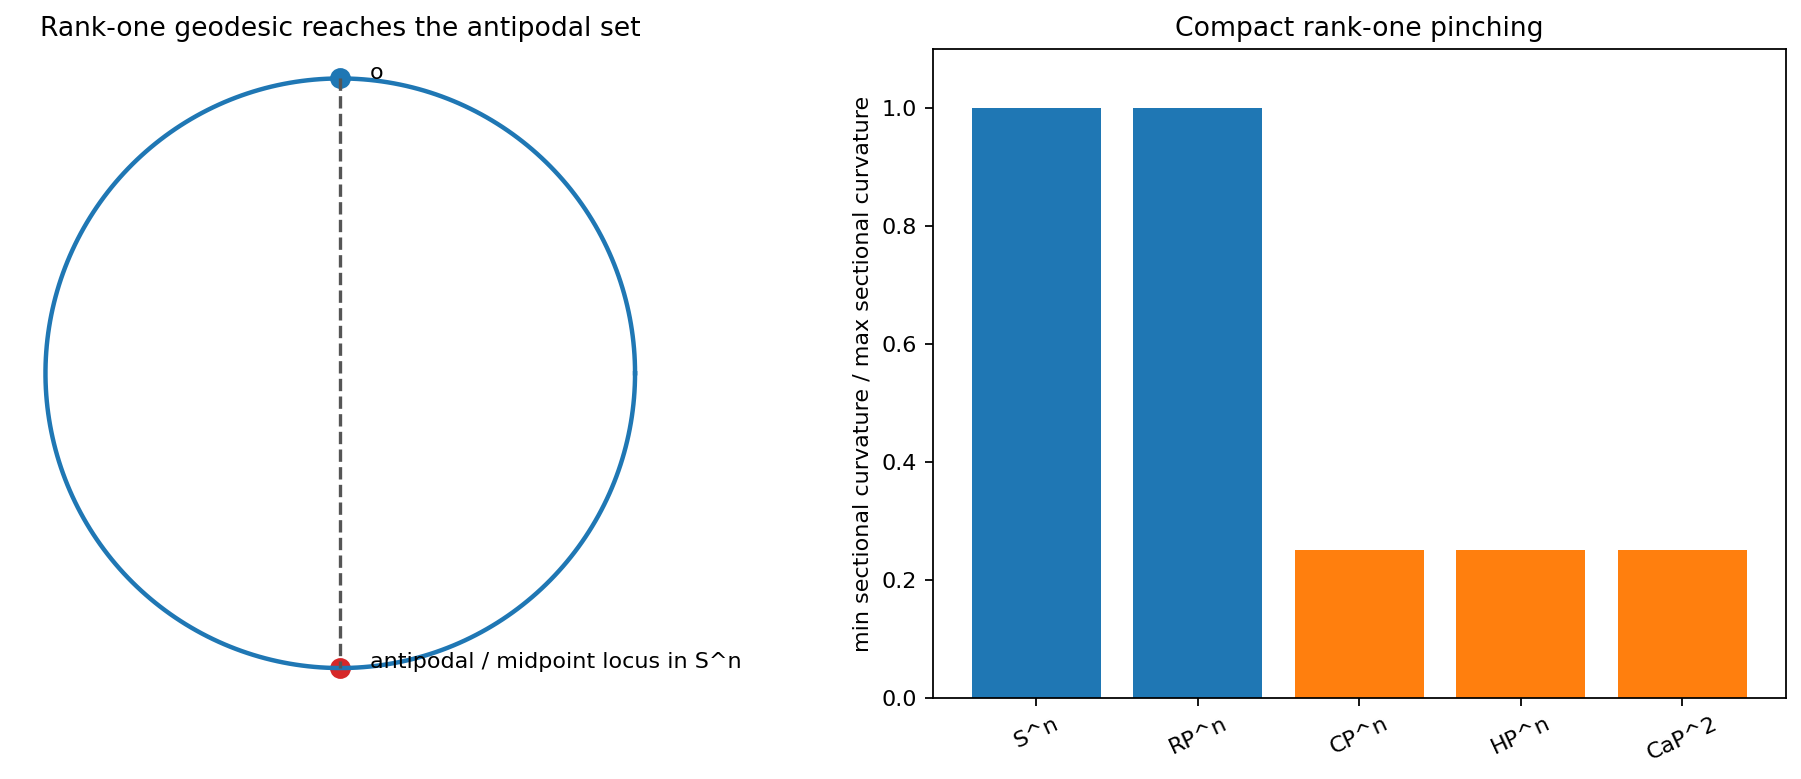

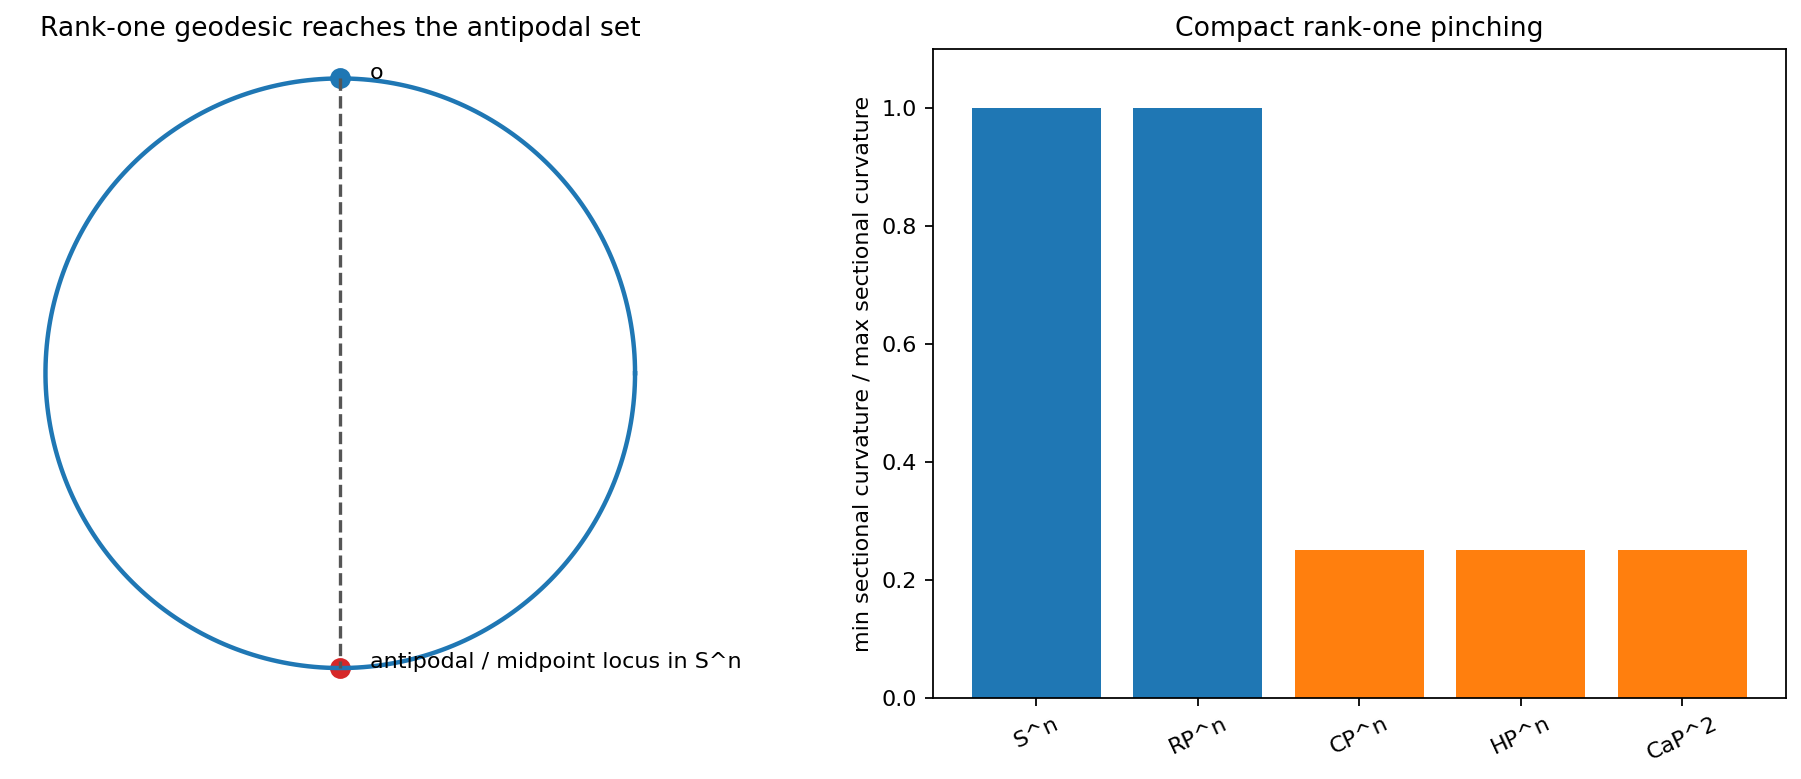

`rank_one_geometry_checks.json`

In [9]:
rank_one_rows = [
    {"space": "S^n", "rank": 1, "curvature_ratio_min_over_max": 1.0, "midpoint_locus": "antipodal point"},
    {"space": "RP^n", "rank": 1, "curvature_ratio_min_over_max": 1.0, "midpoint_locus": "projective hyperplane"},
    {"space": "CP^n", "rank": 1, "curvature_ratio_min_over_max": 0.25, "midpoint_locus": "CP^(n-1)"},
    {"space": "HP^n", "rank": 1, "curvature_ratio_min_over_max": 0.25, "midpoint_locus": "HP^(n-1)"},
    {"space": "CaP^2", "rank": 1, "curvature_ratio_min_over_max": 0.25, "midpoint_locus": "S^8-type locus"},
]
record(save_csv(rank_one_rows, TABLES / "rank_one_curvature_midpoint_models.csv"))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(np.cos(theta), np.sin(theta), color="#1f77b4", lw=2)
axes[0].scatter([0], [1], color="#1f77b4", s=70)
axes[0].scatter([0], [-1], color="#d62728", s=70)
axes[0].text(0.1, 1.0, "o")
axes[0].text(0.1, -1.0, "antipodal / midpoint locus in S^n")
axes[0].plot([0, 0], [1, -1], color="#555555", ls="--")
axes[0].set_title("Rank-one geodesic reaches the antipodal set")
axes[0].set_aspect("equal")
axes[0].axis("off")

spaces = [row["space"] for row in rank_one_rows]
ratios = [row["curvature_ratio_min_over_max"] for row in rank_one_rows]
axes[1].bar(spaces, ratios, color=["#1f77b4", "#1f77b4", "#ff7f0e", "#ff7f0e", "#ff7f0e"])
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel("min sectional curvature / max sectional curvature")
axes[1].set_title("Compact rank-one pinching")
axes[1].tick_params(axis="x", rotation=25)
fig.tight_layout()
path = record(save_matplotlib(fig, FIGURES / "rank_one_midpoint_and_antipodal_geometry.png"))
close_fig(fig)

checks = {
    "rank_one_ratios_are_one_or_quarter": bool(all(row["curvature_ratio_min_over_max"] in {1.0, 0.25} for row in rank_one_rows)),
    "sphere_midpoint_locus_is_point": bool(rank_one_rows[0]["midpoint_locus"] == "antipodal point"),
    "projective_examples_have_nontrivial_midpoint_loci": bool(all("P" in row["space"] for row in rank_one_rows[1:4])),
}
chapter_checks["rank_one_geometry_checks"] = all(checks.values())
record(save_json(checks, CHECKS / "rank_one_geometry_checks.json"))
display_artifact(path)
display_artifact(artifact_paths[-2])
display_artifact(artifact_paths[-1])

## Highest-Root Lab: Where the Shortest Closed Geodesics Live

The shortest closed geodesics are controlled by the highest restricted root.  In a closed Weyl chamber, the highest-root wall is the first affine wall hit by a regular ray normalized to the unit lattice.  The `A2` lab below computes the positive roots, their simple-root heights, and the closed fundamental alcove.  The same logic scales to the root systems used in compact irreducible spaces.

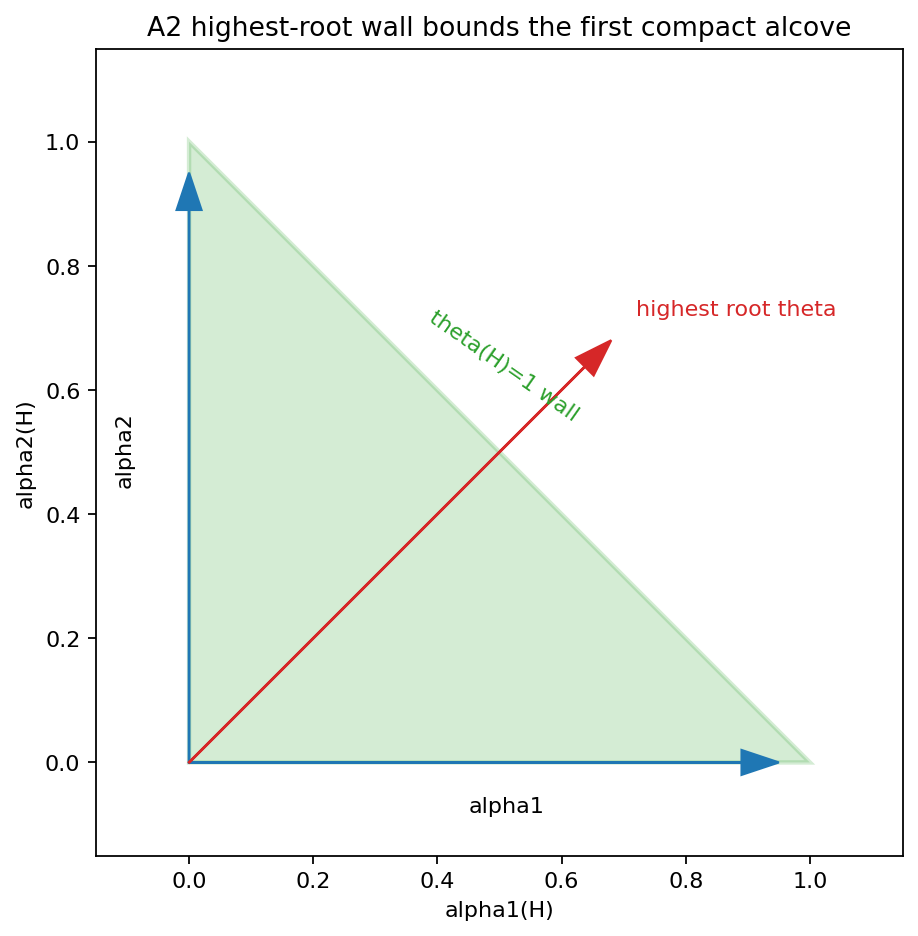

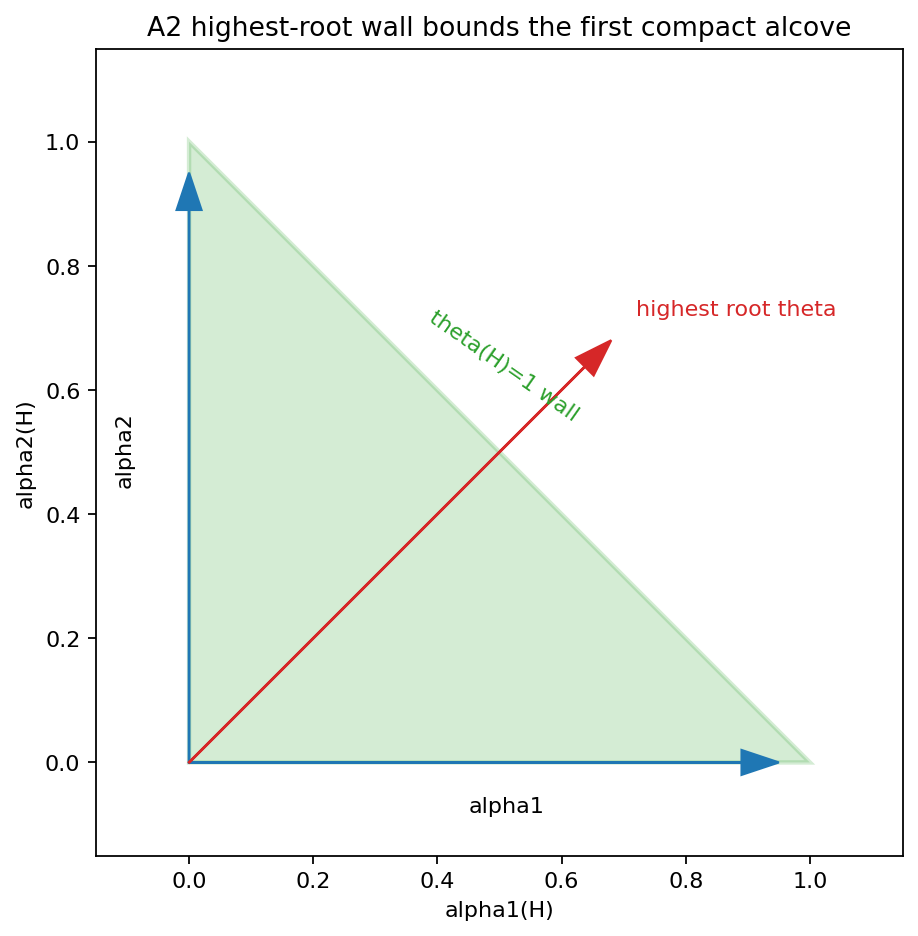

`highest_root_shortest_geodesic_checks.json`

In [10]:
positive_roots_simple_coords = [
    {"root": "alpha1", "alpha1_coeff": 1, "alpha2_coeff": 0},
    {"root": "alpha2", "alpha1_coeff": 0, "alpha2_coeff": 1},
    {"root": "theta=alpha1+alpha2", "alpha1_coeff": 1, "alpha2_coeff": 1},
]
for row in positive_roots_simple_coords:
    row["height"] = row["alpha1_coeff"] + row["alpha2_coeff"]
record(save_csv(positive_roots_simple_coords, TABLES / "highest_root_a2_height_lab.csv"))

fig, ax = plt.subplots(figsize=(7, 6))
ax.add_patch(Polygon(np.array([[0, 0], [1, 0], [0, 1]]), closed=True, facecolor="#2ca02c", alpha=0.2, edgecolor="#2ca02c", lw=2))
ax.arrow(0, 0, 0.95, 0.0, head_width=0.04, length_includes_head=True, color="#1f77b4")
ax.arrow(0, 0, 0.0, 0.95, head_width=0.04, length_includes_head=True, color="#1f77b4")
ax.arrow(0, 0, 0.68, 0.68, head_width=0.04, length_includes_head=True, color="#d62728")
ax.text(0.72, 0.72, "highest root theta", color="#d62728")
ax.text(0.45, -0.08, "alpha1")
ax.text(-0.12, 0.45, "alpha2", rotation=90)
ax.text(0.38, 0.55, "theta(H)=1 wall", color="#2ca02c", rotation=-35)
ax.set_xlim(-0.15, 1.15)
ax.set_ylim(-0.15, 1.15)
ax.set_aspect("equal")
ax.set_title("A2 highest-root wall bounds the first compact alcove")
ax.set_xlabel("alpha1(H)")
ax.set_ylabel("alpha2(H)")
fig.tight_layout()
path = record(save_matplotlib(fig, FIGURES / "highest_root_shortest_geodesic_lab.png"))
close_fig(fig)

max_height = max(row["height"] for row in positive_roots_simple_coords)
highest = [row for row in positive_roots_simple_coords if row["height"] == max_height][0]
checks = {
    "highest_root_has_positive_simple_coefficients": bool(highest["alpha1_coeff"] > 0 and highest["alpha2_coeff"] > 0),
    "highest_root_unique_in_a2": bool(len([row for row in positive_roots_simple_coords if row["height"] == max_height]) == 1),
    "alcove_boundary_is_highest_root_level": bool(highest["root"].startswith("theta")),
}
chapter_checks["highest_root_shortest_geodesic_checks"] = all(checks.values())
record(save_json(checks, CHECKS / "highest_root_shortest_geodesic_checks.json"))
display_artifact(path)
display_artifact(artifact_paths[-2])
display_artifact(artifact_paths[-1])

## 12. Dimension-Theory Appendix as a Geometric Safety Net

The chapter uses the singular set while proving statements about fundamental groups and centers.  The appendix supplies the topology behind the move: if the singular part is small enough, paths and homotopies can be pushed away from it.  The notebook does not reproduce the dimension-theory proofs; instead it records exactly which thresholds the main chapter uses.

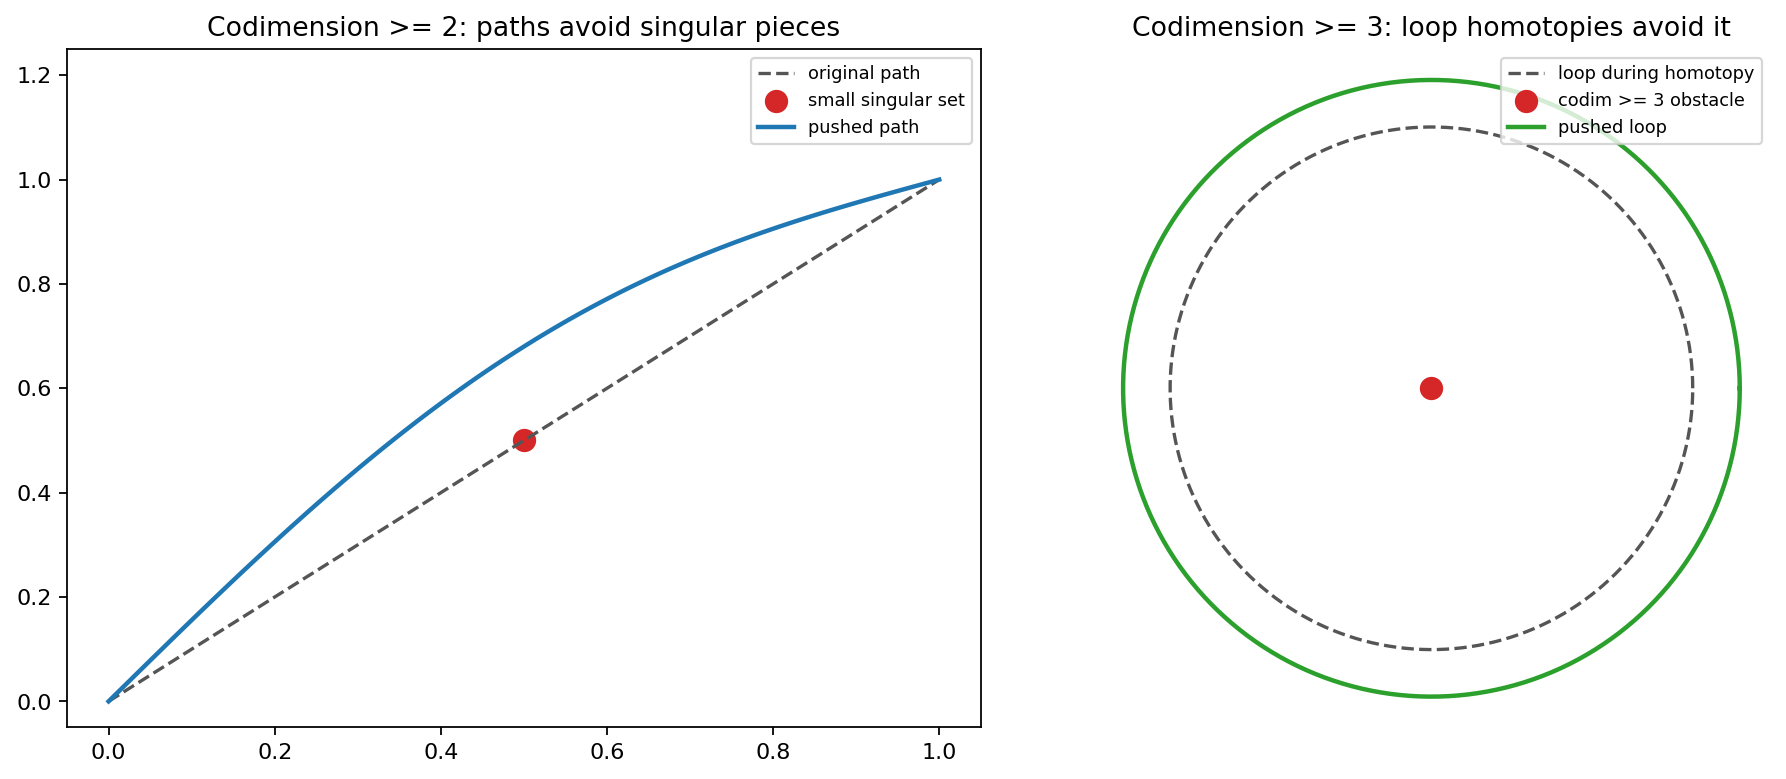

[dimension_theory_appendix_usage.csv](artifacts/chapter-07-symmetric-spaces-of-the-compact-type/tables/dimension_theory_appendix_usage.csv)

`dimension_theory_appendix_checks.json`

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot([0, 1], [0, 1], color="#555555", ls="--", label="original path")
axes[0].scatter([0.5], [0.5], color="#d62728", s=90, label="small singular set")
t = np.linspace(0, 1, 100)
axes[0].plot(t, t + 0.18 * np.sin(np.pi * t), color="#1f77b4", lw=2, label="pushed path")
axes[0].set_title("Codimension >= 2: paths avoid singular pieces")
axes[0].set_xlim(-0.05, 1.05)
axes[0].set_ylim(-0.05, 1.25)
axes[0].legend(fontsize=8)

circle_t = np.linspace(0, 2 * np.pi, 200)
axes[1].plot(np.cos(circle_t), np.sin(circle_t), color="#555555", ls="--", label="loop during homotopy")
axes[1].scatter([0], [0], color="#d62728", s=90, label="codim >= 3 obstacle")
axes[1].plot(1.18 * np.cos(circle_t), 1.18 * np.sin(circle_t), color="#2ca02c", lw=2, label="pushed loop")
axes[1].set_aspect("equal")
axes[1].axis("off")
axes[1].set_title("Codimension >= 3: loop homotopies avoid it")
axes[1].legend(fontsize=8, loc="upper right")
fig.tight_layout()
path = record(save_matplotlib(fig, FIGURES / "dimension_theory_singular_avoidance.png"))
close_fig(fig)

dimension_rows = [
    {"appendix_result": "monotonicity/countable-union dimension estimates", "chapter_use": "control singular strata by lower-dimensional pieces"},
    {"appendix_result": "codimension at least 2 path avoidance", "chapter_use": "work in complement of singular set for path arguments"},
    {"appendix_result": "codimension at least 3 homotopy avoidance", "chapter_use": "fundamental group unaffected by singular set"},
]
record(save_csv(dimension_rows, TABLES / "dimension_theory_appendix_usage.csv"))
checks = {
    "path_avoidance_threshold_codim_two": True,
    "loop_homotopy_threshold_codim_three": True,
    "appendix_connected_to_fundamental_group_argument": bool("fundamental group" in dimension_rows[2]["chapter_use"]),
}
chapter_checks["dimension_theory_appendix_checks"] = all(checks.values())
record(save_json(checks, CHECKS / "dimension_theory_appendix_checks.json"))
display_artifact(path)
display_artifact(artifact_paths[-2])
display_artifact(artifact_paths[-1])

## Applied Lab

Change the simple-root coordinates in the cells above and watch three things at once: which Weyl chamber contains the point, which affine wall is hit first, and which quotient data would identify repeated points.  This is the practical message of Chapter 7.  Compact symmetric spaces are locally controlled by `p` and roots, but globally controlled by the finite Weyl group, the unit lattice, the center, and singular strata.  A point in a flat is not just a coordinate; it is a coordinate modulo all of that structure.

In [12]:
sample_points = [
    {"point": "regular interior", "alpha1": 0.25, "alpha2": 0.30},
    {"point": "Weyl wall", "alpha1": 0.0, "alpha2": 0.40},
    {"point": "affine highest-root wall", "alpha1": 0.55, "alpha2": 0.45},
    {"point": "outside alcove", "alpha1": 0.75, "alpha2": 0.55},
]
for row in sample_points:
    a1, a2 = row["alpha1"], row["alpha2"]
    row["in_closed_alcove"] = bool(a1 >= 0 and a2 >= 0 and a1 + a2 <= 1)
    row["on_weyl_wall"] = bool(abs(a1) < 1e-12 or abs(a2) < 1e-12)
    row["on_highest_affine_wall"] = bool(abs(a1 + a2 - 1) < 1e-12)
record(save_csv(sample_points, TABLES / "compact_flat_point_classifier_lab.csv"))
checks = {
    "regular_interior_classified_inside": bool(sample_points[0]["in_closed_alcove"] and not sample_points[0]["on_weyl_wall"]),
    "weyl_wall_detected": bool(sample_points[1]["on_weyl_wall"]),
    "highest_affine_wall_detected": bool(sample_points[2]["on_highest_affine_wall"]),
    "outside_alcove_detected": bool(not sample_points[3]["in_closed_alcove"]),
}
chapter_checks["compact_flat_classifier_lab_checks"] = all(checks.values())
record(save_json(checks, CHECKS / "compact_flat_classifier_lab_checks.json"))
display_artifact(artifact_paths[-2])
display_artifact(artifact_paths[-1])

[compact_flat_point_classifier_lab.csv](artifacts/chapter-07-symmetric-spaces-of-the-compact-type/tables/compact_flat_point_classifier_lab.csv)

`compact_flat_classifier_lab_checks.json`

## Takeaways

- Compact type keeps the same local symmetric-pair language as noncompact type, but global geometry is folded by periodic geodesics, conjugate points, centers, and lattices.
- Weyl chambers classify regular directions in a maximal flat; affine Weyl alcoves classify compact representatives after unit-lattice translations are included.
- The singular set is not an annoyance to ignore casually: the chapter proves enough dimension-theory control to remove it from path and fundamental-group arguments.
- Rank-one compact spaces make the global story visible: antipodal sets, midpoint loci, curvature pinching, and shortest geodesics are all root-and-lattice phenomena in small scale.

In [13]:
def json_scalar(value):
    if isinstance(value, (bool, np.bool_)):
        return bool(value)
    if hasattr(value, "item"):
        try:
            return value.item()
        except Exception:
            return value
    return value


chapter_checks_json = {name: json_scalar(value) for name, value in chapter_checks.items()}
final_sanity = {
    "chapter": "Chapter VII. Symmetric Spaces of the Compact Type",
    "source_span": "printed pages 281-351, approximately PDF pages 308-378",
    "artifact_count": len(artifact_paths),
    "artifacts": [rel(path) for path in artifact_paths],
    "checks": chapter_checks_json,
    "coverage_note": "Sections 1-12 are represented by compact exponential folding, Weyl/root chamber diagrams, conjugate and singular affine walls, compact group lattice/center checks, affine Weyl alcoves, locally isometric quotient data, rank-one geometry, highest-root shortest-geodesic lab, and dimension-theory avoidance thresholds.",
}
failed = [name for name, value in chapter_checks_json.items() if isinstance(value, bool) and not value]
if failed:
    raise AssertionError(f"Chapter sanity checks failed: {failed}")
final_sanity_path = record(save_json(final_sanity, CHECKS / "final_sanity.json"))
assert_artifacts(artifact_paths, min_bytes=64)
assert_artifacts([final_sanity_path], min_bytes=64)
print(json.dumps({"final_sanity": rel(final_sanity_path), "boolean_checks": len([v for v in chapter_checks_json.values() if isinstance(v, bool)]), "failed": failed}, indent=2))
display_artifact(final_sanity_path)

{
  "final_sanity": "artifacts/chapter-07-symmetric-spaces-of-the-compact-type/checks/final_sanity.json",
  "boolean_checks": 11,
  "failed": []
}


`final_sanity.json`